<!-- TITLE BLOCK -->
<details open>
<summary style="display: block; cursor: pointer; outline: none;">
    <div style="background-color: #4DD0E1; color: #012E40; padding: 10px; border: 1px solid #00ACC1; border-radius: 4px 4px 0 0; font-weight: bold; font-size: 1.1em; letter-spacing: 0.5px;">
        <!-- TYPE TITLE BELOW -->
        JOHN'S COOL PHOTOGRAMMETERY NOTEBOOK<br>
        <!-- TYPE TITLE ABOVE -->
    </div>
</summary>

<!-- BODY BLOCK -->
<div style="background-color: #E0F7FA; color: #012E40; padding: 15px; border: 1px solid #4DD0E1; border-top: none; border-left: 8px solid #00838F; border-radius: 0 0 4px 4px; margin-top: -1px;">
    <div style="font-size: 1.1em;">

<!-- P1:PURPOSE -->
<div style="; margin-top: 8px; margin-bottom: 16px;">
    <div style="font-size: 1.1em; font-weight: bold;">
        <!-- FIRST LINE OF TEXT BELOW -->
        Purpose:
        <!-- FIRST LINE OF TEXT ABOVE -->
    </div>
    <div style="margin-left: 30px;">
        <!-- TYPE INDENTED TEXT HERE -->
        <b style="color: #263238;"></b>This notebook aims to provide an easy-to-follow photogrammetry workflow. There will be a few steps for the user to do to set things up.<br>
        <b style="color: #263238;"></b>From there, it will hopefully be as easy as running some code blocks.<br>
    </div>
</div>

<!-- P2: STEPS-->
<div style="margin-top: 8px; margin-bottom: 16px;">
    <div style="font-size: 1.1em; font-weight: bold; margin-bottom: 8px;">
        <!-- FIRST LINE OF TEXT BELOW -->
        Steps:
        <!-- FIRST LINE OF TEXT ABOVE -->
    </div>
    <div style="margin-left: 30px;">
        <!-- TYPE INDENTED TEXT HERE -->
        <b style="color: #263238;">Step 1:</b> Run the import cells (gives this notebook access to some predefined python tools), and define input/output directories.<br>
        <b style="color: #263238;">Step 2:</b> <i>(optional)</i> Run the metadata checking cells (which use PyExifTool) to check the metadata of your photos and make sure nothing looks awry.<br>
        <b style="color: #263238;">Step 3:</b> Run the photogrammetry cells (which use PyODM), which will create the output model file in the directory you defined earlier.<br>
    </div>

</div>


</div>
</details>


<!-- Title Block -->
<details open>
<summary style="display: block; cursor: pointer; outline: none;">
    <div style="background-color: #4DD0E1; color: #012E40; padding: 10px; border: 1px solid #00ACC1; border-radius: 4px 4px 0 0; font-weight: bold; font-size: 1.1em; letter-spacing: 0.5px;">
        <!-- TYPE TITLE BELOW -->
        STEP 1: Import librabies and define project directories<br>
        <!-- TYPE TITLE ABOVE -->
    </div>
</summary>

<!-- Body Block -->
<div style="background-color: #E0F7FA; color: #012E40; padding: 15px; border: 1px solid #4DD0E1; border-top: none; border-left: 8px solid #00838F; border-radius: 0 0 4px 4px; margin-top: -1px;">
    <div style="font-size: 1em;">

<!-- Body Content -->
<div style="; margin-top: 8px; margin-bottom: 16px;">
    <div style="font-size: 1em">
        <!-- FIRST LINE OF TEXT BELOW -->
        <b style="color: #263238;">Libaries:</b> required libraries for this file are numpy, matplot, PyExifTool, and PyODM. These should be preinstalled in the environment file.<br>
        <b style="color: #263238;">Directories:</b> this notebook needs to know its path on your computer (where the notebook is saved), as well as:<br>
        <!-- FIRST LINE OF TEXT ABOVE -->
    </div>
        <div style="margin-left: 10px;">
        - where your photos are<br>
        - where you want the model to be saved<br>
        - where Exiftool.exe is<br>
        - and, where ODM is installed.
        </div>
    </div>
</details>

In [1]:
# numpy and pandas
import numpy as np
import pandas as pd

# matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import RegularPolygon
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

#path
from pathlib import Path
import os

#photogrammetry tools
#import pyexiftool
import exiftool
#import PyODM (to do later)



<!-- TITLE -->
<details open>
<summary style="display: block; cursor: pointer; outline: none;">
    <div style="background-color: #4DD0E1; color: #012E40; padding: 10px; border: 1px solid #00ACC1; border-radius: 4px 4px 0 0; font-weight: bold; font-size: 1.1em; letter-spacing: 0.5px;">
        <!-- TYPE TITLE BELOW -->
        Define project directories and permissible file types<br>
        <!-- TYPE TITLE ABOVE -->
    </div>
</summary>

<!-- Body Block -->
<div style="background-color: #E0F7FA; color: #012E40; padding: 15px; border: 1px solid #4DD0E1; border-top: none; border-left: 8px solid #00838F; border-radius: 0 0 4px 4px; margin-top: -1px;">
    <div style="font-size: 1em;">

<!-- Body Content -->
<div style="; margin-top: 8px; margin-bottom: 16px;">
    <div style="font-size: 1em">
        <!-- FIRST LINE OF TEXT BELOW -->
        <b style="color: #263238;"></b>To use this notebook, it is expects there to be specific subfolders in the same directory where it is located:<br>
        <!-- FIRST LINE OF TEXT ABOVE -->
    </div>
        <div style="margin-left: 10px; margin-top: 8px">
            <b>- PG_inputs subfolder:</b> store your input photos here.<br>
            <b>- PG_outputs subfolder:</b> where the final outputs will be stored.<br>
            <b>- exiftool-13.51_64:</b> subfolder where exiftool exectubale file (version 13.51) is installed.<br>
            <b>- PyODM tool:</b> _____________<br>
        </div>
    </div>
</details>

In [2]:
# Define project directories
# define current directory of PG_Notebook.ipynb
base_dir = Path.cwd()

# define project subfolders
inputs_dir = base_dir / "PG_inputs"    # this needs to match the name of your input folder
outputs_dir = base_dir / "PG_outputs"  # output files will go in this subfolder

# exiftool path
exif_dir = base_dir / "exiftool-13.51_64" # name of subfolder which contains exiftool.exe
exif_path = str(exif_dir / "exiftool.exe")

# Ensure the output directory exists
outputs_dir.mkdir(exist_ok=True)

In [3]:
# Define the file types we want to process
valid_extensions = {".jpg", ".jpeg", ".png"} # add/remove desired file extensions here. It will only load files of the types listed here.

# Gather all files of specified type
image_files = [
    f for f in inputs_dir.iterdir() 
    if f.suffix.lower() in valid_extensions
]

# Quick status check
print(f"Found {len(image_files)} images in {inputs_dir.name}")

# Show the first few filenames to confirm
for img in image_files[:5]:
    print(f"  {img.name}")


Found 64 images in PG_inputs
  DJI_0245.JPG
  DJI_0246.JPG
  DJI_0247.JPG
  DJI_0248.JPG
  DJI_0249.JPG


<!-- TITLE BLOCK -->
<details open>
<summary style="display: block; cursor: pointer; outline: none;">
    <div style="background-color: #4DD0E1; color: #012E40; padding: 10px; border: 1px solid #00ACC1; border-radius: 4px 4px 0 0; font-weight: bold; font-size: 1.1em; letter-spacing: 0.5px;">
        <!-- TYPE TITLE BELOW -->
        STEP 2: Check image metadata with PyExifTool<br>
        <!-- TYPE TITLE ABOVE -->
    </div>
</summary>

<!-- BODY BLOCK -->
<div style="background-color: #E0F7FA; color: #012E40; padding: 15px; border: 1px solid #4DD0E1; border-top: none; border-left: 8px solid #00838F; border-radius: 0 0 4px 4px; margin-top: -1px;">
    <div style="font-size: 1em;">

<!-- P1: IMPORTANCE OF METADATA CHECKING -->
<div style="; margin-top: 8px; margin-bottom: 16px;">
    <div style="font-size: 1em">
        <!-- FIRST LINE OF TEXT BELOW -->
        <b style="color: #263238;"></b>Checking metadata is an important first step before doing photogrammetry. It allows you to assess data quality immediately, before sinking time into processing it.<br>
        <b style="color: #263238;"></b>For photogrammetry with drones, it is important to make sure the drone's x/y/z positions, roll/pitch/yaw, velocity, and camera settings are in the desired ranges, otherwise<br>
        <b style="color: #263238;"></b>The photogrammetry algorithm may not run properly.<br>
        </div>

<!-- P2: THIS NOTEBOOK'S ASSUMPTIONS ON METADATA -->
<div style="; margin-top: 16px; margin-bottom: 16px;">
    <div style="font-size: 1em">
        <!-- FIRST LINE OF TEXT BELOW -->
        <b style="color: #263238;">THIS NOTEBOOK'S ASSUMPTIONS ABOUT METADATA</b> This notebook was built around processing .jpg images captured on a DJI Mavic Mini drone. DJI drones have specific metadata labels for<br>
        <b style="color: #263238;"></b>the key pieces of metadata this notebook needs (a specific naming convention and structure). Other drones may store metadata in other ways, and may not be compatible with this notebook.<br>
        <b style="color: #263238;"></b>However, this notebook can be used to batch import the metadata (regardless of its naming conventions), so it can help you figure out how to modify this notebook to handle the metadata<br>
        <b style="color: #263238;"></b>of your drone, using the cell below. Generally, as long as you can find the required parameters listed above and assign them properly, you should be able to use this notebook.<br>
        <!-- FIRST LINE OF TEXT ABOVE -->
    </div>
    </div>
</details>

In [5]:
# metadata checking tool - check the metadata of a given file
''' 
This block will import metadata from the specified file, and then allow you to search it for specific strings.
You can use this to figure out exactly what names/tags the drone's pitch, altitude values etc are called in the metadata. This will be required
in order to run the photogrammetry algorithm in Step 3. This notebook is pre-setup to work with DJI Mavic Mini metadata.
For example, for the DJI Mavic Mini, the drone's Roll value is called XMP:FlightRollDegree.
'''

# 1. Setup the target
target_file = inputs_dir / "DJI_0276.jpg" #file name of the one you want to check.

# define search_term -> search metadata table for any entries containing specified string
search_term = "yaw"  # Leave empty (just "") if you want to see everything



# 2. Fetch the metadata
with exiftool.ExifToolHelper(executable=exif_path) as et:
    # get_metadata returns a list; we take the first element [0]
    full_metadata = et.get_metadata(str(target_file))[0]

# 3. Create a clean, sorted DataFrame
df_meta = pd.DataFrame(list(full_metadata.items()), columns=['Tag Name', 'Value'])
df_meta = df_meta.sort_values(by='Tag Name').reset_index(drop=True)

# 4. Search Tool: Change 'search_term' to find what you need (e.g., "GPS", "Gimbal", "Yaw")

filtered_df = df_meta[df_meta['Tag Name'].str.contains(search_term, case=False)]

# 5. Display (using head(50) so it doesn't explode the notebook, or remove .head() to see all)
display(filtered_df)


,Tag Name,Value
109,MakerNotes:CameraYaw,1.2
116,MakerNotes:Yaw,141.699997
125,XMP:FlightYawDegree,+141.70
130,XMP:GimbalYawDegree,+1.20


In [5]:
# This block prints all the metadata tags and values for the specified file

# The specific file you want to inspect
target_file = inputs_dir / "Chris Jaz Engagement photo.jpg"#"DJI_0276.JPG" #change target file name here

with exiftool.ExifToolHelper(executable=exif_path) as et:
    # Fetch metadata for the single target file
    metadata_list = et.get_metadata(str(target_file))
    metadata = metadata_list[0]
    
    print(f"{'TAG NAME':<35} | {'VALUE'}")
    print("-" * 60)
    
    # Print sorted tags with their corresponding values
    for tag_name in sorted(metadata.keys()):
        val = metadata[tag_name]
        print(f"{tag_name:<35} | {val}")

print(f"\n--- Total Tags Found: {len(metadata)} ---")


TAG NAME                            | VALUE
------------------------------------------------------------
Composite:ImageSize                 | 959 960
Composite:Megapixels                | 0.92064
ExifTool:ExifToolVersion            | 13.51
File:BitsPerSample                  | 8
File:ColorComponents                | 3
File:Directory                      | C:/Users/jamac/Desktop/School Work/MEng/EOSC 556 Applied Geophysics/Project/PG_notebook/PG_inputs
File:EncodingProcess                | 0
File:FileAccessDate                 | 2026:03:23 11:50:22-07:00
File:FileCreateDate                 | 2026:03:23 11:34:05-07:00
File:FileModifyDate                 | 2023:08:10 12:55:43-07:00
File:FileName                       | Chris Jaz Engagement photo.jpg
File:FilePermissions                | 100666
File:FileSize                       | 83296
File:FileType                       | JPEG
File:FileTypeExtension              | JPG
File:ImageHeight                    | 960
File:ImageWidth           

<!-- TITLE -->
<details open>
<summary style="display: block; cursor: pointer; outline: none;">
    <div style="background-color: #4DD0E1; color: #012E40; padding: 10px; border: 1px solid #00ACC1; border-radius: 4px 4px 0 0; font-weight: bold; font-size: 1.1em; letter-spacing: 0.5px;">
        <!-- TYPE TITLE BELOW -->
        Define list of attributes, and the specific names for each parameter in your metadata<br>
        <!-- TYPE TITLE ABOVE -->
    </div>
</summary>

<!-- Body Block -->
<div style="background-color: #E0F7FA; color: #012E40; padding: 15px; border: 1px solid #4DD0E1; border-top: none; border-left: 8px solid #00838F; border-radius: 0 0 4px 4px; margin-top: -1px;">
    <div style="font-size: 1em;">

<!-- Body Content -->
<div style="; margin-top: 8px; margin-bottom: 16px;">
    <div style="font-size: 1em">
        <!-- FIRST LINE OF TEXT BELOW -->
        <b style="color: #263238;"></b>In the following block, you must define the specific names for each parameter found in the metadata of the images you're using.<br>
                                    The entire codebase following this cell uses general terms such as drone_lat, or drone_lon to refer to parameters, but you have to tell it what<br>
                                    the specific names for these terms are in your metadata. For a DJI Mavic Mini, it would be "Composite:GPSLatitude" and "Composite:GPSLongitude".<br>
        <!-- FIRST LINE OF TEXT ABOVE -->
        </div>
    </div>
</details>

In [6]:
# --- Metadata Parameter Definition ---

# Edit these if you switch drone manufacturers/models.
# The terms on the left are the notebook's names for each parameter. The right side should have your specific terms used in your metadata
TAG_LIST = {
    # Core Parameters
    "drone_lat":     "Composite:GPSLatitude", #change all the terms on the right of the colons to match your metadata
    "drone_lon":     "Composite:GPSLongitude",
    "drone_el":      "XMP:RelativeAltitude",
    "cam_yaw":       "XMP:GimbalYawDegree",
    "cam_pitch":     "XMP:GimbalPitchDegree",
    "cam_roll":      "XMP:GimbalRollDegree",
    "focal_mm":      "EXIF:FocalLength",
    
    # Diagnostic Parameters
    "cam_shutter":   "EXIF:ExposureTime",
    "cam_iso":       "EXIF:ISO",
    "cam_aperture":  "EXIF:FNumber",
    "drone_vx":      "MakerNotes:SpeedX",
    "drone_vy":      "MakerNotes:SpeedY",
    "drone_vz":      "MakerNotes:SpeedZ",
    "drone_roll":    "XMP:FlightRollDegree",
    "drone_pitch":   "XMP:FlightPitchDegree",
    "drone_yaw":     "XMP:FlightYawDegree",
    "timestamp":     "EXIF:DateTimeOriginal"
}


In [7]:
'''
Once the specific names have been defined (above), run this code to batch import the metadata from each photo into
two dataframes that they can be used/analyzed in this notebook.

'''

core_list = []
diag_list = []

with exiftool.ExifToolHelper(executable=exif_path) as et:
    all_meta = et.get_metadata([str(f) for f in image_files])

    for meta in all_meta:
        fname = Path(meta["SourceFile"]).name
        
        # Build Core Table Row (The must-haves for the model)
        core_list.append({
            "FileName":  fname,
            "drone_lat":  meta.get(TAG_LIST.get("drone_lat")),
            "drone_lon":  meta.get(TAG_LIST.get("drone_lon")),
            "drone_el":   meta.get(TAG_LIST.get("drone_el")),
            "cam_yaw":    meta.get(TAG_LIST.get("cam_yaw")),
            "cam_pitch":  meta.get(TAG_LIST.get("cam_pitch")),
            "focal_mm":   meta.get(TAG_LIST.get("focal_mm"))
        })
        
        # Build Diagnostic Table Row (The quality checks)
        diag_list.append({
            "FileName":      fname,
            "cam_shutter":   meta.get(TAG_LIST.get("cam_shutter")),
            "cam_iso":       meta.get(TAG_LIST.get("cam_iso")),
            "cam_aperture":  meta.get(TAG_LIST.get("cam_aperture")),
            "drone_vx":      meta.get(TAG_LIST.get("drone_vx")),
            "drone_vy":      meta.get(TAG_LIST.get("drone_vy")),
            "drone_vz":      meta.get(TAG_LIST.get("drone_vz")),
            "drone_roll":    meta.get(TAG_LIST.get("drone_roll")),
            "drone_pitch":   meta.get(TAG_LIST.get("drone_pitch")),
            "drone_yaw":     meta.get(TAG_LIST.get("drone_yaw")),
            "timestamp":     meta.get(TAG_LIST.get("timestamp"))
        })

# Create DataFrames and convert to numeric (turns "+0.5" string into a number of "0.5")
# 1. Create the DataFrames normally
Core_Metadata = pd.DataFrame(core_list)
Diagnostic_Metadata = pd.DataFrame(diag_list)

# These columns should remain as strings (stored as text)
string_cols = ["FileName", "timestamp"]

# 3. Apply numeric conversion to the other columns that weren't listed to expect strings
for df in [Core_Metadata, Diagnostic_Metadata]:
    # Get list of columns that AREN'T in our string list
    cols_to_fix = [c for c in df.columns if c not in string_cols]
    
    # Convert those columns to numeric, turning junk into NaN
    df[cols_to_fix] = df[cols_to_fix].apply(pd.to_numeric, errors='coerce')

print(f"Processed {len(image_files)} images into the DataFrames.")


Processed 64 images into the DataFrames.


<!-- TITLE -->
<details open>
<summary style="display: block; cursor: pointer; outline: none;">
    <div style="background-color: #4DD0E1; color: #012E40; padding: 10px; border: 1px solid #00ACC1; border-radius: 4px 4px 0 0; font-weight: bold; font-size: 1.1em; letter-spacing: 0.5px;">
        <!-- TYPE TITLE BELOW -->
        Optional: Check if any imported photos are missing key metadata parameters<br>
        <!-- TYPE TITLE ABOVE -->
    </div>
</summary>

<!-- Body Block -->
<div style="background-color: #E0F7FA; color: #012E40; padding: 15px; border: 1px solid #4DD0E1; border-top: none; border-left: 8px solid #00838F; border-radius: 0 0 4px 4px; margin-top: -1px;">
    <div style="font-size: 1em;">

<!-- Body Content -->
<div style="; margin-top: 8px; margin-bottom: 16px;">
    <div style="font-size: 1em">
        <!-- FIRST LINE OF TEXT BELOW -->
        <b style="color: #263238;"></b>Run the cell below to look for any empty entries in our dataframe, (ie photos without lat/lon/altitude etc).<br>
                                    The following cell can be run to remove empty entries/ignore photos with incomplete metadata.<br>
        <!-- FIRST LINE OF TEXT ABOVE -->
        </div>
    </div>
</details>

In [8]:
# --- BLOCK 1: LIVE DATA INTEGRITY CHECK ---

# 1. Identify rows with ANY NaN (Not a Number) values in the DataFrames
# We check Core_Metadata for the drone location/angles
bad_rows = Core_Metadata[Core_Metadata.isnull().any(axis=1)]

# 2. Extract those filenames into our list
incomplete_photos = []
for _, row in bad_rows.iterrows():
    # Identify which columns specifically are missing (NaN)
    missing = row[row.isnull()].index.tolist()
    incomplete_photos.append({
        "FileName": row["FileName"],
        "Missing": missing
    })

# 3. Report findings
if incomplete_photos:
    print(f"--- ⚠️ DATA INTEGRITY WARNING ({len(incomplete_photos)} Files) ---")
    for item in incomplete_photos:
        print(f"FILE: {item['FileName']} | Missing Values: {', '.join(item['Missing'])}")
else:
    print("✅ DataFrames are clean! No missing entries found.")


✅ DataFrames are clean! No missing entries found.


In [9]:
# # run this to check if any of the photos added to the data frame were empty
# incomplete_photos = []

# # Check both lists for any 'None' values
# for i in range(len(core_list)):
#     # Combine keys from both to see the full picture for that file
#     combined_entry = {**core_list[i], **diag_list[i]}
    
#     # Identify which specific keys are missing data
#     missing_keys = [k for k, v in combined_entry.items() if v is None]
    
#     if missing_keys:
#         incomplete_photos.append({
#             "FileName": combined_entry["FileName"],
#             "Missing": missing_keys
#         })

# # Report findings
# if incomplete_photos:
#     print(f"--- ⚠️ DATA INTEGRITY WARNING ({len(incomplete_photos)} Files) ---")
#     for item in incomplete_photos:
#         print(f"FILE: {item['FileName']}")
#         print(f"  > Missing Tags: {', '.join(item['Missing'])}")
#     print("\nTip: These files will likely cause errors in PyODM or mapping. Consider removing them from PG_inputs and rerunning data import cells")
# else:
#     print("✅ Data Integrity Verified: All mapped tags found for all images.")


In [10]:
# --- Data Cleaning: Remove Incomplete Photos ---

# Initialize as empty if the previous cell wasn't run
if 'incomplete_photos' not in locals():
    incomplete_photos = []

filenames_to_drop = [item['FileName'] for item in incomplete_photos]

# 1. Extract the list of filenames that failed the integrity check
filenames_to_drop = [item['FileName'] for item in incomplete_photos]

if filenames_to_drop:
    # 2. Filter the DataFrames
    # The ~ operator means "NOT" (keep rows where FileName is NOT in the list)
    Core_Metadata = Core_Metadata[~Core_Metadata['FileName'].isin(filenames_to_drop)].reset_index(drop=True)
    Diagnostic_Metadata = Diagnostic_Metadata[~Diagnostic_Metadata['FileName'].isin(filenames_to_drop)].reset_index(drop=True)
    
    print(f"--- Data Cleaning Complete ---")
    print(f"Dropped {len(filenames_to_drop)} rows from Core and Diagnostic tables.")
    print(f"Remaining images for processing: {len(Core_Metadata)}")
    
    # 3. EMPTY the list so it doesn't trigger again on a re-run
    incomplete_photos = []
    
else:
    print("✅ No incomplete photos found. DataFrames are already clean!")


✅ No incomplete photos found. DataFrames are already clean!


<!-- TITLE -->
<details open>
<summary style="display: block; cursor: pointer; outline: none;">
    <div style="background-color: #4DD0E1; color: #012E40; padding: 10px; border: 1px solid #00ACC1; border-radius: 4px 4px 0 0; font-weight: bold; font-size: 1.1em; letter-spacing: 0.5px;">
        <!-- TYPE TITLE BELOW -->
        Metadata of your metadata<br>
        <!-- TYPE TITLE ABOVE -->
    </div>
</summary>

<!-- Body Block -->
<div style="background-color: #E0F7FA; color: #012E40; padding: 15px; border: 1px solid #4DD0E1; border-top: none; border-left: 8px solid #00838F; border-radius: 0 0 4px 4px; margin-top: -1px;">
    <div style="font-size: 1em;">

<!-- Body Content -->
<div style="; margin-top: 8px; margin-bottom: 8px;">
    <div style="font-size: 1em">
        <!-- FIRST LINE OF TEXT BELOW -->
        <b style="color: #263238;"></b>In the following block, a summary of key metadata related to the drone's position and speed is generated from your metadata.<br>
        <!-- FIRST LINE OF TEXT ABOVE -->
        </div>
    </div>
</details>

In [11]:
# --- Summary Report of Drone Physics ---

# 1. Define columns - which parameters to include from the two dataframes
core_physics = ['drone_el']
diag_physics = ['drone_vx', 'drone_vy', 'drone_vz', 'drone_roll', 'drone_pitch', 'drone_yaw']

# 2. Combine columns into a temp dataframe
report_df = pd.concat([
    Core_Metadata[core_physics], 
    Diagnostic_Metadata[diag_physics]
], axis=1)

# 3. Run the stats
physics_stats = report_df.agg(['min', 'max', 'mean', 'median', 'std']).round(2)

print("--- Drone Physics Summary ---")
display(physics_stats)


--- Drone Physics Summary ---


,drone_el,drone_vx,drone_vy,drone_vz,drone_roll,drone_pitch,drone_yaw
min,49.30,-0.20,0.00,-0.10,1.60,1.20,141.60
max,50.70,0.10,0.20,0.10,4.90,8.10,142.20
mean,50.02,-0.00,0.00,0.00,3.53,4.45,141.97
median,50.00,0.00,0.00,0.00,3.50,4.40,142.00
std,0.29,0.03,0.03,0.02,0.57,1.10,0.12


In [12]:
# Note on roll, pitch, yaw:

# roll axis: from nose to tail of the drone. rotation about this axis would make one wing lower and one wing higher
# pitch axis: from wing to wing. pitching the "nose" up or down.
# yaw: rotation about the vertical axis. which bearing the drone is pointing at.

In [14]:
# --- Camera Settings Consistency Report (Enhanced with Inline Status) ---

# 1. Define the parameters and store their most common values (modes)
check_params = {
    "cam_shutter": Diagnostic_Metadata,
    "cam_iso": Diagnostic_Metadata,
    "cam_aperture": Diagnostic_Metadata,
    "focal_mm": Core_Metadata
}

total_photos = len(image_files)
outlier_filenames = set()
param_modes = {}

print(f"--- Camera Consistency Report (Total Photos: {total_photos}) ---\n")
print(f"{'Parameter':<15} | {'Unique':<8} | {'Most Common':<12} | {'Frequency'}")
print("-" * 60)

for param, df in check_params.items():
    counts = df[param].value_counts()
    num_unique = len(counts)
    most_common_val = counts.index[0]
    param_modes[param] = most_common_val # Save for the detailed report below
    freq = counts.iloc[0]
    
    if num_unique > 1:
        outliers = df[df[param] != most_common_val]['FileName'].tolist()
        outlier_filenames.update(outliers)
    
    status = "✅" if num_unique == 1 else "⚠️"
    print(f"{param:<15} | {num_unique:<8} | {most_common_val:<12} | {freq}/{total_photos} {status}")

# 2. Enhanced Detailed Outlier Report
if outlier_filenames:
    print(f"\n--- ⚠️ NON-STANDARD PHOTOS DETECTED ({len(outlier_filenames)}) ---")
    for fname in sorted(list(outlier_filenames)):
        d_row = Diagnostic_Metadata[Diagnostic_Metadata['FileName'] == fname].iloc[0]
        c_row = Core_Metadata[Core_Metadata['FileName'] == fname].iloc[0]
        
        # Helper to pick the emoji
        def get_stat(val, mode):
            return "✅" if val == mode else "⚠️"

        s_stat = get_stat(d_row['cam_shutter'], param_modes['cam_shutter'])
        i_stat = get_stat(d_row['cam_iso'], param_modes['cam_iso'])
        a_stat = get_stat(d_row['cam_aperture'], param_modes['cam_aperture'])
        f_stat = get_stat(c_row['focal_mm'], param_modes['focal_mm'])

        print(f"FILE: {fname}")
        print(f"  > {s_stat}Shutter: {d_row['cam_shutter']} | "
              f"{i_stat}ISO: {d_row['cam_iso']} | "
              f"{a_stat}Aperture: {d_row['cam_aperture']} | "
              f"{f_stat}Focal: {c_row['focal_mm']}mm")
else:
    print("\n✅ All camera settings are perfectly uniform across the dataset.")


--- Camera Consistency Report (Total Photos: 64) ---

Parameter       | Unique   | Most Common  | Frequency
------------------------------------------------------------
cam_shutter     | 1        | 0.002        | 64/64 ✅
cam_iso         | 1        | 100          | 64/64 ✅
cam_aperture    | 1        | 2.8          | 64/64 ✅
focal_mm        | 1        | 4.49         | 64/64 ✅

✅ All camera settings are perfectly uniform across the dataset.


<!-- TITLE -->
<details open>
<summary style="display: block; cursor: pointer; outline: none;">
    <div style="background-color: #4DD0E1; color: #012E40; padding: 10px; border: 1px solid #00ACC1; border-radius: 4px 4px 0 0; font-weight: bold; font-size: 1.1em; letter-spacing: 0.5px;">
        <!-- TYPE TITLE BELOW -->
        Plotting your flight path<br>
        <!-- TYPE TITLE ABOVE -->
    </div>
</summary>

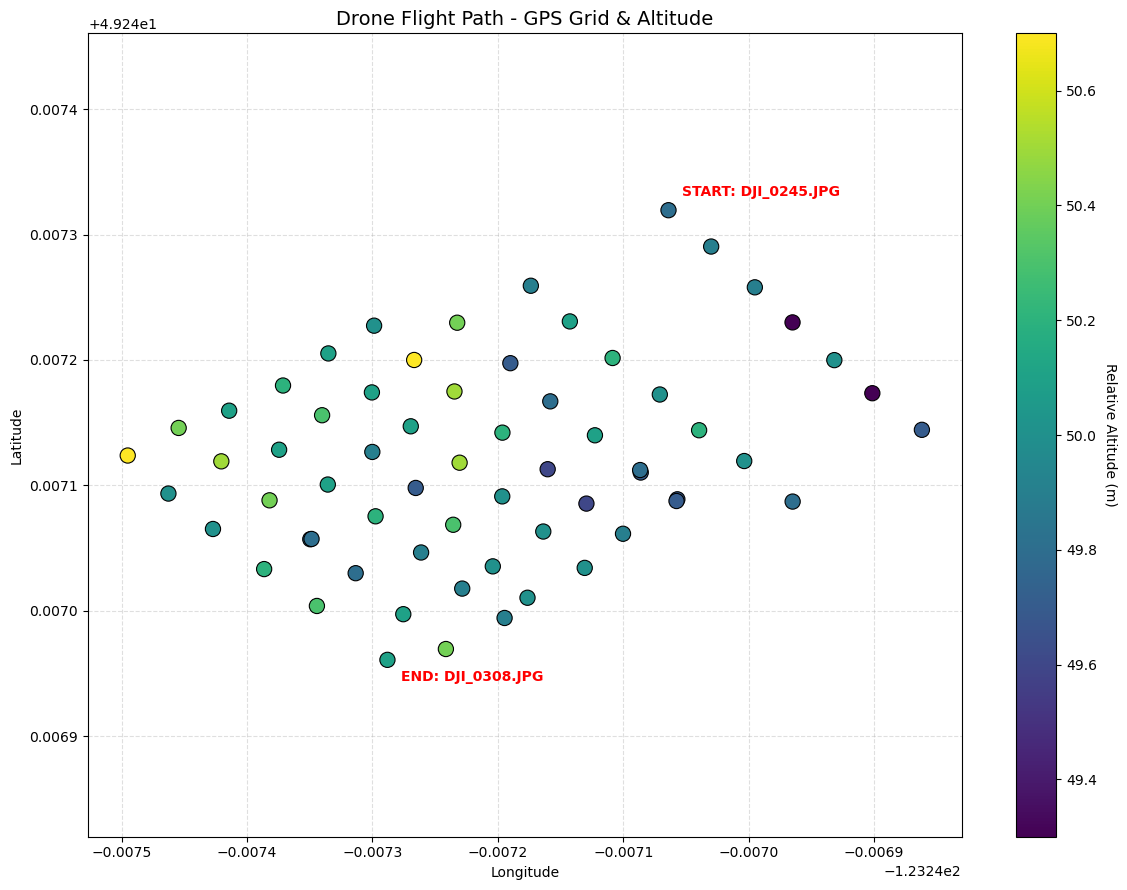

Plotting 64 images. Sequence: DJI_0245.JPG to DJI_0308.JPG


In [15]:
'''
Flight Path Plotter:
Takes x/y/z of each photo and plots them on a scatterplot with a colour range for elevation.
This is useful for visualizing your flight path and assessing grid quality, coverage, etc.

Run the cell with "save_plot = True" to automatically export, or with "False" if you don't want.

'''

# --- Plot Settings ---
save_plot = False  
plot_title = 'Drone Flight Path - GPS Grid & Altitude' # The output file (if save_plot=True) will also have this as the filename

# 1. Identify start and end filenames
start_name = Core_Metadata['FileName'].iloc[0]
end_name = Core_Metadata['FileName'].iloc[-1]

# 2. Setup the Plot
fig, ax = plt.subplots(figsize=(12, 9))

# 3. Create Scatter with Altitude Heatmap
scatter = ax.scatter(
    Core_Metadata['drone_lon'], 
    Core_Metadata['drone_lat'], 
    c=Core_Metadata['drone_el'], 
    cmap='viridis', 
    s=120, 
    edgecolor='black',
    linewidth=0.8,
    zorder=3
)

# 4. Add Colorbar
cbar = fig.colorbar(scatter)
cbar.set_label('Relative Altitude (m)', rotation=270, labelpad=15)

# 5. Add Labels for Start and End
ax.annotate(
    f'START: {start_name}', 
    (Core_Metadata['drone_lon'].iloc[0], Core_Metadata['drone_lat'].iloc[0]),
    textcoords="offset points", xytext=(10,10), 
    color='red', weight='bold', fontsize=10
)

ax.annotate(
    f'END: {end_name}', 
    (Core_Metadata['drone_lon'].iloc[-1], Core_Metadata['drone_lat'].iloc[-1]),
    textcoords="offset points", xytext=(10,-15), 
    color='red', weight='bold', fontsize=10
)

# 6. Formatting
ax.set_title(plot_title, fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.axis('equal') 
ax.grid(True, linestyle='--', alpha=0.4)

# 7. Save to Output Directory using the title as the filename
if save_plot:
    save_path = outputs_dir / f"{plot_title}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved to: {save_path}")

plt.tight_layout()
plt.show()

print(f"Plotting {len(Core_Metadata)} images. Sequence: {start_name} to {end_name}")
